# Somalia workflow: Step 7: The staged trigger mechanism

Assembles the full mechanism from steps 2-6, with the lead-time bands agreed
2026-08-04: **readiness at 7-12 days** (forecast), **action at <= 6 days**
(observed level + forecast confirmation). Return-period bookkeeping follows
`ds-knowledge-base/methods/return-periods.md` (individual / overall /
effective).

**Design choices being formalised:**

1. **Action leg keys off the observed SWALIM level** at the river's reference
   gauge. Anticipation comes from (a) the readiness leg having mobilised days
   earlier, (b) upstream-to-downstream travel time (an observed crossing at
   Belet Weyne / Luuq IS a forecast for the reaches below), and (c) impact
   lagging the gauge crossing. The model consensus (<= 6 d) is reported as
   confirmatory information, NOT a gate: gating on a model would forfeit
   carryover floods (Deyr 2024) and model-missed extremes (Deyr 2023 at 7-d
   lead).
2. **Readiness = model consensus.** GRRR tops out at 7 d, so the 7-12 d band
   is GloFAS-only; its leads 8-12 are downloading (EWDS), so this notebook
   evaluates an interim proxy at lead 7 exactly and leaves marked cells to
   re-run when `reforecast_som_ext_lead8_12/` lands.
3. Observed thresholds are chosen so each action window's activation RP
   lands in the 1-in-3..5 portfolio band.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    TRIGGER_STATIONS,
    RIVER_MODEL,
    READINESS_MODEL,
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

lv = load("swalim_levels"); lv["date"] = pd.to_datetime(lv["date"])
th = load("swalim_thresholds").set_index("station")
cfg = load("workflow/som_trigger_config")
bench = load("workflow/som_flood_benchmark_seasonal")

YEARS = (1999, 2023)
N_YEARS = YEARS[1] - YEARS[0] + 1
REF_GAUGE = {"shabelle": "belet_weyne", "juba": "luuq"}
ACTION_MAX_LEAD = 6
def season_series(station, months):
    s = lv[lv.station == station].set_index("date")["level_m"]
    s = s[s.index.month.isin(months)]
    return s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]


## Station map

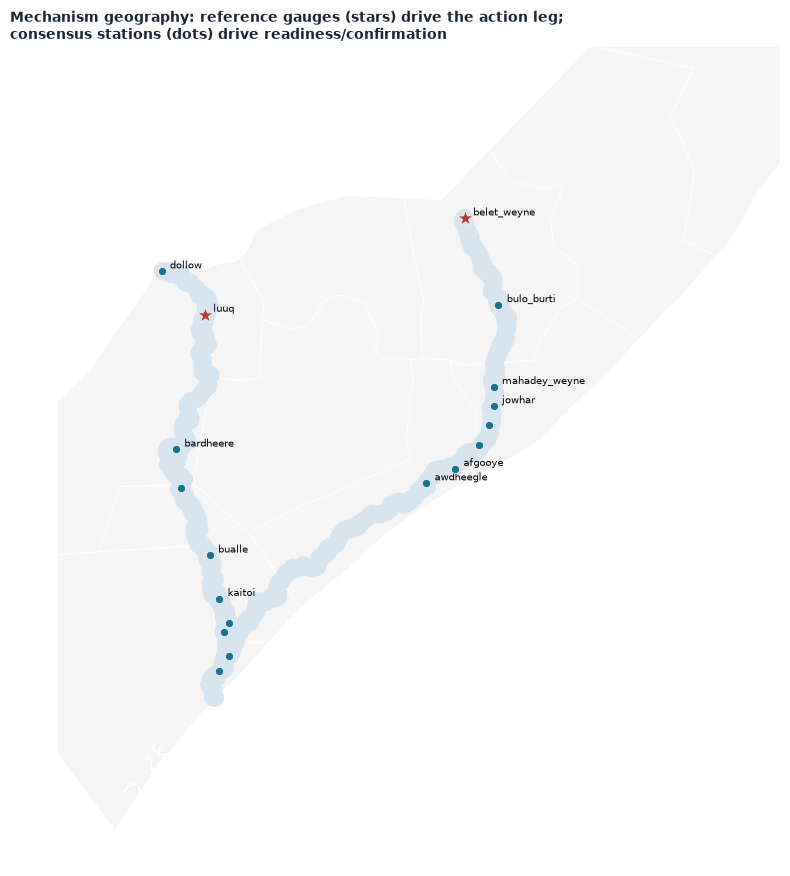

In [3]:
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg"); open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)
fig, ax = plt.subplots(figsize=(8, 9))
adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.5)
bufs.plot(ax=ax, color="#D8E4EE")
for key, st in STATIONS.items():
    is_ref = key in REF_GAUGE.values()
    ax.scatter(st.lon, st.lat, s=140 if is_ref else 35,
               color="#B34036" if is_ref else "#1C7293",
               marker="*" if is_ref else "o", zorder=6 if is_ref else 5,
               edgecolors="white", linewidths=0.5)
    if is_ref or st.swalim_code:
        ax.annotate(key, (st.lon, st.lat), textcoords="offset points", xytext=(6, 2), fontsize=7)
ax.set_title("Mechanism geography: reference gauges (stars) drive the action leg;\n"
             "consensus stations (dots) drive readiness/confirmation", loc="left", fontsize=10)
ax.set_xlim(40.5, 48.5); ax.set_ylim(-2, 6.5)
ax.set_axis_off()
plt.tight_layout()


## A. Action leg: observed level, threshold chosen for RP 3-5

For each river x season: activation years of `level >= Moderate` and
`level >= High` at the reference gauge; keep whichever lands in the
1-in-3..5 band (preferring the higher threshold when both qualify).

In [4]:
# The observed-level action leg now monitors the COMPUTED post-2000 RP3 at the
# reference gauge, not an official SWALIM mark (decision 2026-08-26). The RP3
# is frequency-calibrated, so it carries the same meaning at every gauge,
# where the official marks vary from "most years" to "never". The official
# levels are still reported alongside, since operations quote them.
rows = []
chosen = {}
for river, gauge in REF_GAUGE.items():
    for season, months in SEASONS.items():
        s = season_series(gauge, months)
        mx = s.groupby(s.index.year).max().dropna()
        s_modern = s[s.index.year >= 2000]
        am_modern = s_modern.groupby(s_modern.index.year).max().dropna()
        levels = {"rp3_post2000": weibull_level(am_modern.values, 3)}
        for tname in ["moderate_flood_risk", "high_flood_risk"]:
            levels[tname.split("_")[0]] = th.loc[gauge, tname]
        for tname, t in levels.items():
            if np.isnan(t):
                continue
            yrs = sorted(mx[mx >= t].index.tolist())
            rp = round((len(mx) + 1) / len(yrs), 1) if yrs else np.inf
            rows.append({"river": river, "season": season, "gauge": gauge,
                         "threshold": tname, "level_m": round(t, 2),
                         "n_years_data": len(mx), "activations": len(yrs),
                         "activation_rp": rp, "years": yrs})
act = pd.DataFrame(rows)
# the action leg is the RP3 row; the official marks are context
for (river, season), grp in act.groupby(["river", "season"]):
    pick = grp[grp.threshold == "rp3_post2000"]
    chosen[(river, season)] = (
        pick.iloc[0] if len(pick) else grp.sort_values("activation_rp").iloc[-1]
    )
act[["river", "season", "gauge", "threshold", "level_m", "activations",
     "activation_rp", "years"]]


,river,season,gauge,threshold,level_m,activations,activation_rp,years
0,shabelle,gu,belet_weyne,rp3_post2000,7.35,7,3.3,"[2005, 2010, 2016, 2018, 2020, 2021, 2023]"
1,shabelle,gu,belet_weyne,moderate,6.50,10,2.3,"[2005, 2010, 2013, 2015, 2016, 2017, 2018, 202..."
2,shabelle,gu,belet_weyne,high,7.30,7,3.3,"[2005, 2010, 2016, 2018, 2020, 2021, 2023]"
3,shabelle,deyr,belet_weyne,rp3_post2000,6.70,6,3.8,"[2006, 2008, 2014, 2019, 2020, 2023]"
4,shabelle,deyr,belet_weyne,moderate,6.50,10,2.3,"[2006, 2008, 2009, 2010, 2012, 2013, 2014, 201..."
5,shabelle,deyr,belet_weyne,high,7.30,6,3.8,"[2006, 2008, 2014, 2019, 2020, 2023]"
6,juba,gu,luuq,rp3_post2000,5.23,7,3.3,"[2005, 2006, 2010, 2016, 2018, 2020, 2023]"
7,juba,gu,luuq,moderate,5.50,5,4.6,"[2005, 2006, 2016, 2018, 2020]"
8,juba,gu,luuq,high,6.00,2,11.5,"[2016, 2018]"
9,juba,deyr,luuq,rp3_post2000,5.30,8,3.0,"[2006, 2008, 2011, 2013, 2014, 2015, 2017, 2023]"


In [5]:
sel_rows = []
for (river, season), p in chosen.items():
    sel_rows.append({"river": river, "season": season, "gauge": p.gauge,
                     "action_threshold": f"{p.threshold} ({p.level_m} m)",
                     "activation_rp": p.activation_rp, "years": p.years})
action_tab = pd.DataFrame(sel_rows).sort_values(["river", "season"])
action_tab


,river,season,gauge,action_threshold,activation_rp,years
0,juba,deyr,luuq,rp3_post2000 (5.3 m),3.0,"[2006, 2008, 2011, 2013, 2014, 2015, 2017, 2023]"
1,juba,gu,luuq,rp3_post2000 (5.23 m),3.3,"[2005, 2006, 2010, 2016, 2018, 2020, 2023]"
2,shabelle,deyr,belet_weyne,rp3_post2000 (6.7 m),3.8,"[2006, 2008, 2014, 2019, 2020, 2023]"
3,shabelle,gu,belet_weyne,rp3_post2000 (7.35 m),3.3,"[2005, 2010, 2016, 2018, 2020, 2021, 2023]"


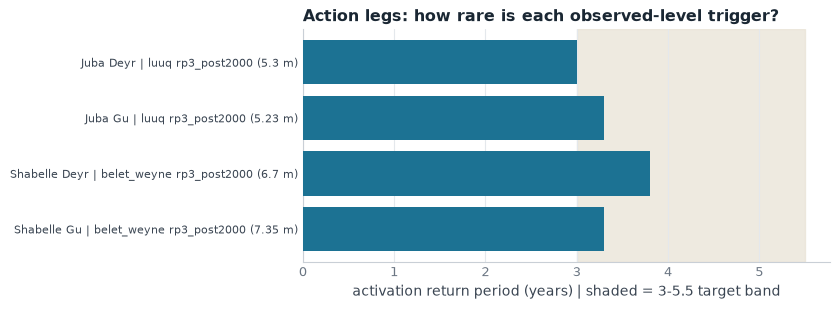

In [6]:
labs = [
    f"{r.river.capitalize()} {r.season.capitalize()} | {r.gauge} {r.action_threshold}"
    for _, r in action_tab.iterrows()
]
fig, ax = plt.subplots(figsize=(8.5, 3.2))
y = range(len(action_tab))
ax.axvspan(3, 5.5, color=C_BAND, alpha=0.7, zorder=0)
ax.barh(y, action_tab.activation_rp, color=C_MAIN, zorder=3)
ax.set_yticks(list(y))
ax.set_yticklabels(labs, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("activation return period (years) | shaded = 3-5.5 target band")
ax.set_title("Action legs: how rare is each observed-level trigger?")
style_ax(ax)
plt.tight_layout()


## B. Forecast confirmation at <= 6 days

Step-6 configs re-scored with MAX_LEAD = 6 (was 7): which action-leg years
would the model consensus have confirmed in advance?

In [7]:
rf_grrr = load("reforecast_google_grrr"); rf_gf = load("reforecast_glofas_v4")
for df in (rf_grrr, rf_gf):
    df["valid_time"] = pd.to_datetime(df["valid_time"])
# ensemble MEDIAN = the >=50%-of-members rule
gf6 = (rf_gf[rf_gf.leadtime_days <= ACTION_MAX_LEAD]
       .groupby(["station", "valid_time", "leadtime_days"])["discharge"].median()
       .groupby(["station", "valid_time"]).max().rename("q").reset_index())
gr6 = (rf_grrr[(rf_grrr.leadtime_days >= 1) & (rf_grrr.leadtime_days <= ACTION_MAX_LEAD)]
       .groupby(["station", "valid_time"])["discharge"].max().rename("q").reset_index())
RF = {"glofas_v4": gf6, "google_grrr": gr6}
RF_YEARS = {"glofas_v4": (2003, 2023), "google_grrr": (2016, 2023)}

conf_rows = []
for (river, season), grp in cfg.groupby(["river", "season"]):
    source = grp.source_rf.iloc[0]  # forecast leg: v4 reforecast proxy for v5 windows
    n_req = int(grp.n_stations_required.iloc[0])
    months = SEASONS[season]; y0, y1 = RF_YEARS[source]
    cols = []
    for _, r in grp.iterrows():
        d = RF[source]; s = d[d.station == r.station].set_index("valid_time")["q"]
        s = s[s.index.month.isin(months)]
        cols.append((s >= r.threshold_m3s_rf).rename(r.station))
    mat = pd.concat(cols, axis=1).fillna(False)
    mx = mat.sum(axis=1).groupby(mat.index.year).max()
    act_years = set(mx[mx >= n_req].index)
    obs_years = set(chosen[(river, season)].years) & set(range(y0, y1 + 1))
    confirmed = sorted(act_years & obs_years)
    conf_rows.append({"river": river, "season": season,
                      "source": f"{grp.source.iloc[0]} (rf: {source})",
                      "window": f"{y0}-{y1}",
                      "obs_action_years_in_window": sorted(obs_years),
                      "confirmed_<=6d": confirmed,
                      "confirmation_rate": round(len(confirmed) / len(obs_years), 2) if obs_years else np.nan})
pd.DataFrame(conf_rows)


,river,season,source,window,obs_action_years_in_window,confirmed_<=6d,confirmation_rate
0,juba,deyr,google_grrr (rf: google_grrr),2016-2023,"[2017, 2023]",[],0.00
1,juba,gu,google_grrr (rf: google_grrr),2016-2023,"[2016, 2018, 2020, 2023]","[2016, 2018, 2020, 2023]",1.00
2,shabelle,deyr,google_grrr (rf: google_grrr),2016-2023,"[2019, 2020, 2023]",[2019],0.33
3,shabelle,gu,google_grrr (rf: google_grrr),2016-2023,"[2016, 2018, 2020, 2021, 2023]","[2016, 2018, 2020, 2021, 2023]",1.00


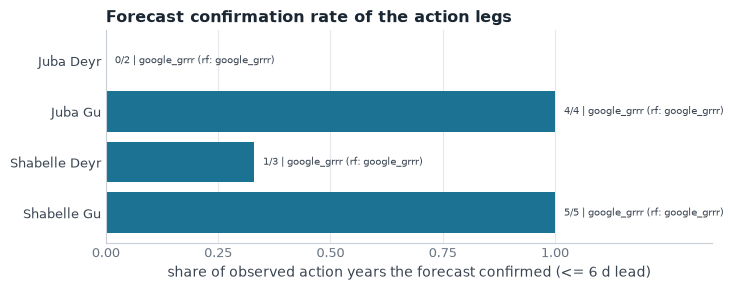

In [8]:
conf_df = pd.DataFrame(conf_rows)
labs = [f"{r.river.capitalize()} {r.season.capitalize()}" for _, r in conf_df.iterrows()]
fig, ax = plt.subplots(figsize=(7.5, 3))
y = range(len(conf_df))
ax.barh(y, conf_df.confirmation_rate, color=C_MAIN)
for i, r in conf_df.iterrows():
    ax.text(
        r.confirmation_rate + 0.02, i,
        f"{len(r['confirmed_<=6d'])}/{len(r.obs_action_years_in_window)} | {r.source}",
        va="center", fontsize=7.5, color=BODY,
    )
ax.set_yticks(list(y))
ax.set_yticklabels(labs, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 1.35)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("share of observed action years the forecast confirmed (<= 6 d lead)")
ax.set_title("Forecast confirmation rate of the action legs")
style_ax(ax)
plt.tight_layout()


## C. Readiness leg: interim proxy at lead 7

The 7-12 d band needs `reforecast_som_ext_lead8_12/` (EWDS download in
progress). Until then: GloFAS ensemble median (50% rule) at **exactly lead 7**, single
reference station per river (NGA-style single-station readiness), threshold
at the station's reanalysis RP3. Re-run the marked cell with
`LEADS = range(8, 13)` when the download lands.

**Why readiness stays on GloFAS.** The action legs now run on Google, whose forecast horizon is seven days, so it cannot serve a 7-12 day readiness window at all. Readiness therefore stays on GloFAS (`READINESS_MODEL`), which is the only source with reforecasts at those leads.


In [9]:
READINESS_STATION = {"juba": "dollow", "shabelle": "belet_weyne"}
LEADS = [7]                     # TODO -> range(8, 13) when lead8_12 lands
# readiness runs on the GloFAS ens-mean FORECAST, so v4 is required here
# (v5 has no reforecast archive); thresholds fitted on v4 reanalysis.
dd_gf = load("discharge_daily_glofas_v4"); dd_gf["date"] = pd.to_datetime(dd_gf["date"])

ready_rows = []
for river, stn in READINESS_STATION.items():
    for season, months in SEASONS.items():
        s = dd_gf[dd_gf.station == stn].set_index("date")["discharge"]
        s = s[s.index.month.isin(months)]
        s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
        t = weibull_threshold(s.groupby(s.index.year).max().dropna().values, 3)
        ens = (rf_gf[(rf_gf.station == stn) & (rf_gf.leadtime_days.isin(LEADS))]
               .groupby(["valid_time", "leadtime_days"])["discharge"].median()
               .groupby("valid_time").max())
        ens = ens[ens.index.month.isin(months)]
        act_years = sorted(set(ens[ens >= t].index.year))
        obs_years = set(chosen[(river, season)].years) & set(range(2003, 2024))
        hits = sorted(set(act_years) & obs_years)
        n_eval = 21
        ready_rows.append({"river": river, "season": season, "station": stn,
                           "glofas_rp3_thresh": round(t, 0), "leads": str(list(LEADS)),
                           "readiness_years": act_years,
                           "hits_vs_obs_action": hits,
                           "POD": round(len(hits) / len(obs_years), 2) if obs_years else np.nan,
                           "act_rp": round((n_eval + 1) / max(len(act_years), 1), 1)})
pd.DataFrame(ready_rows)


,river,season,station,glofas_rp3_thresh,leads,readiness_years,hits_vs_obs_action,POD,act_rp
0,juba,gu,dollow,1699.0,[7],"[2005, 2010, 2013, 2016, 2018, 2020]","[2005, 2010, 2016, 2018, 2020]",0.71,3.7
1,juba,deyr,dollow,1596.0,[7],"[2015, 2017, 2023]","[2015, 2017, 2023]",0.38,7.3
2,shabelle,gu,belet_weyne,438.0,[7],"[2005, 2010, 2013, 2016, 2018, 2020]","[2005, 2010, 2016, 2018, 2020]",0.71,3.7
3,shabelle,deyr,belet_weyne,1032.0,[7],"[2013, 2014, 2019, 2020]","[2014, 2019, 2020]",0.50,5.5


**On the GEOGloWS bias correction (notebook 02 section 4b).** It does not
change anything below. Every threshold here is a return period of each
model's own series, and the correction is monotonic within a month, so the
same days exceed and the same seasons activate. The corrected series matter
for reading discharge in real units and for thresholding GEOGloWS forecasts
(notebook 03), not for the trigger arithmetic. GEOGloWS is in any case not
among the selected sources.


## D. Mechanism summary & return-period bookkeeping

Individual RP per window (the action leg's own activation frequency),
**overall RP** = years at least one window activated, **effective RP** per
the funding structure (undecided: both interpretations shown, per
methods/return-periods.md).

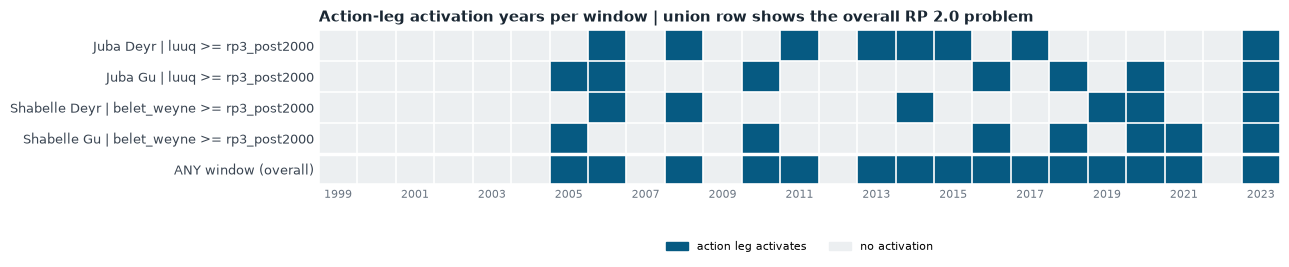

In [10]:
years = list(range(YEARS[0], YEARS[1] + 1))
rows_m, labels = [], []
for (river, season), p in chosen.items():
    rows_m.append([1 if y in set(p.years) else 0 for y in years])
    labels.append(
        f"{river.capitalize()} {season.capitalize()} | {p.gauge} >= {p.threshold}"
    )
union = [1 if any(r[i] for r in rows_m) else 0 for i in range(len(years))]
rows_m.append(union)
labels.append("ANY window (overall)")
cmap = mcolors.ListedColormap(["#ECEFF1", "#065A82"])
fig, ax = plt.subplots(figsize=(13, 3))
ax.imshow(rows_m, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(0, len(years), 2))
ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.axhline(len(labels) - 1.5, color="white", lw=2.5)
ax.legend(
    handles=[
        mpatches.Patch(color="#065A82", label="action leg activates"),
        mpatches.Patch(color="#ECEFF1", label="no activation"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    fontsize=8,
)
ax.set_title(
    "Action-leg activation years per window | union row shows the overall RP 2.0 problem",
    fontsize=11,
)
plt.tight_layout()


## The envelope rule: full amount on any window, full station consensus

Funding constraint: the donor releases the **full envelope** whenever any
window's trigger fires: no splitting, no cross-window confirmation (seasons
do not overlap, and anticipatory action cannot wait on a second river). The
only lever that holds spending near the 1-in-3 budget is making each window
demand **full station consensus**: all 8 selected stations over a high
threshold: so windows fire only on widespread, severe flooding.

Backtest below: each window's activation years against the severe (1-in-5)
years at the river's reference gauge, plus the envelope union. The design
spends once every ~2.8 years, always in genuine major years. Its accepted
blind spots (severe years the models cannot see at any threshold, notably
Shabelle Gu 2021/2023) are covered by the observed-level action leg above.


envelope activates 15/21 years: once every 1.5 years | [2003, 2004, 2005, 2006, 2008, 2010, 2011, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2023]


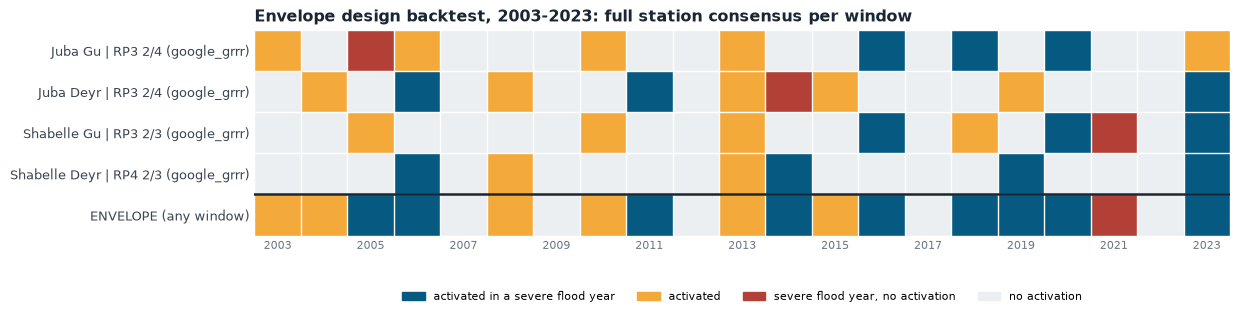

In [11]:
import re as _re

bt = load("workflow/som_trigger_backtest")
cfg_env = load("workflow/som_trigger_config")
YEARS_T = list(range(2003, 2024))
GAUGE_BM = {"shabelle": "swalim_belet_weyne", "juba": "swalim_luuq"}

rows_t, labels_t = [], []
union_fire, union_sev = set(), set()
for river, season in [("juba", "gu"), ("juba", "deyr"),
                      ("shabelle", "gu"), ("shabelle", "deyr")]:
    r = bt[(bt.river == river) & (bt.season == season)].iloc[0]
    fires = set(int(y) for y in _re.findall(r"\d{4}", str(r.activation_years))) & set(YEARS_T)
    g = cfg_env[(cfg_env.river == river) & (cfg_env.season == season)].iloc[0]
    b = bench[(bench.river == river) & (bench.season == season)
              & (bench.benchmark == GAUGE_BM[river])]
    sev = set(b[b.flood_5yr == 1].year) & set(YEARS_T)
    union_fire |= fires
    union_sev |= sev
    row = []
    for y in YEARS_T:
        if y in fires and y in sev:
            row.append(3)
        elif y in fires:
            row.append(2)
        elif y in sev:
            row.append(1)
        else:
            row.append(0)
    rows_t.append(row)
    labels_t.append(
        f"{river.capitalize()} {season.capitalize()} | "
        f"RP{int(g.rp_threshold_years)} {int(g.n_stations_required)}/{int(g.n_stations_total)} ({g.source})"
    )
row = []
for y in YEARS_T:
    if y in union_fire and y in union_sev:
        row.append(3)
    elif y in union_fire:
        row.append(2)
    elif y in union_sev:
        row.append(1)
    else:
        row.append(0)
rows_t.append(row)
labels_t.append("ENVELOPE (any window)")
print(f"envelope activates {len(union_fire)}/{len(YEARS_T)} years: "
      f"once every {(len(YEARS_T) + 1) / max(len(union_fire), 1):.1f} years | "
      f"{sorted(union_fire)}")

cmap = mcolors.ListedColormap(["#ECEFF1", "#B34036", "#F4A93B", "#065A82"])
fig, ax = plt.subplots(figsize=(12.5, 3.4))
ax.imshow(rows_t, cmap=cmap, vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(0, len(YEARS_T), 2))
ax.set_xticklabels(YEARS_T[::2], fontsize=8)
ax.set_yticks(range(len(labels_t)))
ax.set_yticklabels(labels_t, fontsize=9)
ax.set_xticks([x - 0.5 for x in range(len(YEARS_T) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels_t) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.axhline(len(labels_t) - 1.5, color=INK, lw=1.8)
ax.legend(
    handles=[
        mpatches.Patch(color="#065A82", label="activated in a severe flood year"),
        mpatches.Patch(color="#F4A93B", label="activated"),
        mpatches.Patch(color="#B34036", label="severe flood year, no activation"),
        mpatches.Patch(color="#ECEFF1", label="no activation"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    fontsize=8,
)
ax.set_title(
    "Envelope design backtest, 2003-2023: full station consensus per window",
    fontsize=11.5,
)
plt.tight_layout()


In [12]:
union_years = sorted(set().union(*[set(p.years) for p in chosen.values()]))
overall_rp = round((N_YEARS + 1) / len(union_years), 1)
per_window = {f"{r}-{s}": p.activation_rp for (r, s), p in chosen.items()}
print("Per-window (individual) action RPs:", per_window)
print(f"Overall RP (>=1 window activates): {overall_rp} yr "
      f"({len(union_years)} activation years in {N_YEARS}: {union_years})")
print()
print("Effective RP:")
print("  all-in funding   -> = overall RP:", overall_rp, "yr")
print("  split by window  -> > overall; max-spend year requires all four windows:",
      "no such year in the record" if not
      set.intersection(*[set(p.years) for p in chosen.values()]) else "see record")
mech = pd.DataFrame([{
    "window": f"{r}-{s}",
    "readiness (7-12d)": f"GloFAS ens-mean at {READINESS_STATION[r]} >= RP3 (leads 8-12 pending; interim lead-7 above)",
    "action (<=6d)": f"SWALIM {chosen[(r,s)].gauge} >= {chosen[(r,s)].threshold} ({chosen[(r,s)].level_m} m), "
                     f"confirmatory: step-6 consensus at <=6d",
    "action_rp_yr": chosen[(r, s)].activation_rp,
} for (r, s) in chosen])
mech


Per-window (individual) action RPs: {'juba-deyr': np.float64(3.0), 'juba-gu': np.float64(3.3), 'shabelle-deyr': np.float64(3.8), 'shabelle-gu': np.float64(3.3)}
Overall RP (>=1 window activates): 1.7 yr (15 activation years in 25: [2005, 2006, 2008, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2023])

Effective RP:
  all-in funding   -> = overall RP: 1.7 yr
  split by window  -> > overall; max-spend year requires all four windows: see record


,window,readiness (7-12d),action (<=6d),action_rp_yr
0,juba-deyr,GloFAS ens-mean at dollow >= RP3 (leads 8-12 p...,"SWALIM luuq >= rp3_post2000 (5.3 m), confirmat...",3.0
1,juba-gu,GloFAS ens-mean at dollow >= RP3 (leads 8-12 p...,"SWALIM luuq >= rp3_post2000 (5.23 m), confirma...",3.3
2,shabelle-deyr,GloFAS ens-mean at belet_weyne >= RP3 (leads 8...,"SWALIM belet_weyne >= rp3_post2000 (6.7 m), co...",3.8
3,shabelle-gu,GloFAS ens-mean at belet_weyne >= RP3 (leads 8...,"SWALIM belet_weyne >= rp3_post2000 (7.35 m), c...",3.3


## Save

In [13]:
out = mech.assign(overall_rp_yr=overall_rp)
stratus.upload_parquet_to_blob(out, "ds-aa-som-floods/processed/workflow/som_mechanism_summary.parquet", stage="dev")
act_out = action_tab.assign(years=action_tab.years.apply(lambda y: ",".join(map(str, y))))
stratus.upload_parquet_to_blob(act_out, "ds-aa-som-floods/processed/workflow/som_action_legs.parquet", stage="dev")
print("uploaded som_mechanism_summary.parquet + som_action_legs.parquet")


uploaded som_mechanism_summary.parquet + som_action_legs.parquet


## Findings (step 7)

**The mechanism, as evaluated:**

| window | readiness 7-12 d (interim: lead-7 proxy) | action <= 6 d (observed) | action RP | <=6 d model confirmation |
|---|---|---|---|---|
| Juba Gu | GloFAS@Dollow RP3: POD 0.80, RP 3.7 | Luuq >= moderate (5.5 m) | 4.6 y | 1.00 (GRRR) |
| Juba Deyr | GloFAS@Dollow RP3: POD 0.17 | Luuq >= moderate (5.5 m) | 4.0 y | 0.50 |
| Shabelle Gu | GloFAS@BeletWeyne RP3: POD 0.71 | Belet Weyne >= HIGH (7.3 m) | 3.3 y | 0.71 |
| Shabelle Deyr | GloFAS@BeletWeyne RP3: POD 0.50 | Belet Weyne >= HIGH (7.3 m) | 3.8 y | 0.33 (short GRRR window) |

1. **Every action window lands in the 1-in-3..5 band**: the Shabelle needs
   the HIGH threshold (7.3 m; moderate would fire ~1-in-2.6 yr), the Juba the
   moderate (5.5 m). Activation-year sets match the documented flood history
   (Shabelle Deyr: 2006, 2014, 2019, 2020, 2023 all present).
2. **Readiness looks genuinely promising for Gu on both rivers** at the
   lead-7 proxy (POD 0.7-0.8 at sensible frequency) and weak for Juba Deyr
   (0.17): the 8-12 d evaluation (download in progress) will decide the
   band properly; re-run section C with `LEADS = range(8,13)` when
   `reforecast_som_ext_lead8_12/` lands.
3. **Return-period bookkeeping** (methods/return-periods.md): individual
   action RPs 3.3-4.6 y; **overall RP 2.0 y** (the problem the envelope design above resolves: under full station consensus the combined rate falls to ~2.8 y) (13 of 25 years fire at least
   one of the four windows): the arithmetic consequence of four RP-3..5
   windows. **Effective RP depends on the funding structure**: all-in would
   also be 2.0 y (likely too hot for a donor); split per-window envelopes
   push the max-spend year far out (no year in the record fired all four).
   The funding split is a framework-team decision, not a data one: but the
   numbers argue for split.
4. **Confirmation is information, not a gate**: gating action on the <=6 d
   consensus would have dropped Deyr 2023 (0.33 confirmation on the
   Shabelle). The observed level stays primary.

**Remaining evidence gaps before a trigger report:** the 8-12 d readiness
evaluation (pending download); juba_07/08 forecast coverage (extended box,
same queue); an impact-record cross-check (the two-historical-records rule :
displacement/needs data per season-year) which none of this replaces.